<a href="https://colab.research.google.com/github/Laura-Filkova/CB2330-KICKASS-PROJECT/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project card

**The paper:**
Ginell, Emenecker, Lotthammer, Keeley, Plassmeyer, Razo, Usher, Pelham and Holehouse (2025). ***Sequence-based prediction of intermolecular interactions driven by disordered regions.*** *Science* 388, eadq8381. doi:10.1126/science.adq8381

**The data object:**
Supplementary Table S3 (`data/NIHMS2095256-supplement-Table_S3.xlsx`). Sheet S3A has 19,702 human intrinsically disordered regions (IDRs). Each row has the IDR sequence before phosphorylation (`sequence_pre`), the sequence after every experimentally reported phosphosite (S/T/Y) was replaced by glutamic acid (`sequence_post`), and the homotypic interaction parameter ε that FINCHES predicts for both (`epsilon_pre`, `epsilon_post`). Negative ε means the IDR attracts copies of itself, positive ε means it repels them. Sheet S3B is the same calculation with a second force field. In 2,131 rows the two sequences are identical; we leave those out of the fit and use them as a check. That leaves 17,571 IDRs.

**The random variable chosen:**
$\Delta\varepsilon = \varepsilon_\text{post} - \varepsilon_\text{pre}$ for one IDR, the change in self-interaction caused by phosphorylation. Positive $\Delta\varepsilon$ means the IDR became more repulsive. We model it given $n$, the number of positions where `sequence_pre` and `sequence_post` differ, which is the number of phosphosites converted to E.

**What the paper does:**
The paper introduces FINCHES, which predicts from sequence alone how strongly disordered regions interact. As one application, it computes ε for all human IDRs with phosphosites before and after phosphomimetic mutation, and reports that about 57% become less self-attractive and about 30% more self-attractive. These percentages match sheet S3B. The paper does not model how the size of the change depends on the number of sites.

**The generative model proposed:**
Each phosphosite changes ε by its own random amount, and the amounts add up:

$$\Delta\varepsilon = \delta_1 + \delta_2 + \dots + \delta_n, \qquad \delta_k \sim \mathcal{N}(\mu, s^2)$$

Since a sum of independent normals is normal, with means and variances adding:

$$\Delta\varepsilon \mid n \sim \mathcal{N}(n\mu,\; n s^2)$$

Mechanism: FINCHES builds ε from residue-by-residue interaction terms, so replacing one residue changes only the terms involving that residue, and each replacement contributes its own piece to the total. The pieces differ because each site sits in a different sequence context, which we treat as random. Without any extra fitting, the model predicts a straight line through zero (no sites, no change), a spread that grows with √n (the fan in the scatter plot), and a right-skewed pooled histogram (a mixture of narrow distributions for IDRs with few sites and wide ones for IDRs with many).

**Parameters and assumptions:**

| parameter | meaning | unit | larger value does |
|---|---|---|---|
| μ | average change in ε per phosphosite | ε units per site | cloud rises more steeply with n |
| s | site-to-site variation of that change | ε units per √site | fan opens wider with n |

Assumptions:
1. Each site's effect adds to the others; the added glutamates do not interact with each other.
2. Sites are independent, also within the same IDR.
3. All per-site effects come from the same normal distribution, whatever the protein, IDR length or neighbouring residues.
4. IDRs are independent of each other.
5. The count of changed letters equals the number of phosphosites.

**The forward simulation:**
`simulate_idr` draws one normal amount per site and adds them up; `simulate_dataset` does this for every IDR using its real n. Normal draws come from the course's linear congruential generator, as the sum of 12 uniforms minus 6 (mean 0, variance 1; checked on 20,000 draws). A simulated Table S3A at μ = 0.9, s = 1.3 reproduces the straight rise and the fan of the real data, with fewer extreme points at large n.

**The parameterization/fitting:**
Maximum likelihood.  

The negative log-likelihood is

$$\text{NLL}(\mu, s) = -\sum_{i=1}^{N} \ln f\left(\Delta\varepsilon_i \mid n_i\mu,\ \sqrt{n_i}\,s\right)$$


summed over the 17,571 IDRs, with the log of the normal density written out to avoid underflow. A grid search over 41 × 41 pairs gives **$\hat\mu$ = 0.927 ε units per site** and **$\hat s$ = 1.34**, matching the closed-form maximum ($\hat\mu$ = total $\Delta\varepsilon$ / total sites).

Checks:
- *Parameter recovery:* 10 datasets simulated at μ = 0.90, s = 1.30 refit to 0.899 and 1.300 on average.
- *Uncertainty on μ:* likelihood interval 0.924 to 0.931 (±0.0036), curvature error bar ±0.0037, bootstrap (200 resamples) ±0.0054. The bootstrap is wider because it does not rely on the model's spread, which is too narrow for IDRs with many sites.
- *Sanity check:* all 2,131 IDRs without a changed site have Δε = 0 exactly, as the model requires.

**What/if the model adds to the paper:**
- One number for the effect of a single phosphosite on IDR self-interaction (about 0.93 ε units with the S3A force field, 0.26 with S3B).
- Phosphorylation's effect scales with the number of sites
- A prediction the paper does not make: the share of IDRs that become stickier after phosphorylation should fall as n grows. The data follow this trend: in S3A, 17% of IDRs with 1 site become stickier, and 2% of IDRs with 10 sites.

**Model limitations/how it breaks:**
- *Variance:* the variance does not grow like n. The model overestimates the spread for IDRs with 1 to 3 sites and underestimates it for IDRs with many (predicted 35.9 vs observed 51.0 at n = 20). Sites in the same IDR are probably not independent (assumption 2), or the per-site effect differs between proteins (assumption 3).
- *Fraction of stickier IDRs:* because the spread is too wide at small n, the model overpredicts the fraction of IDRs that become stickier there (24% predicted vs 17% observed at n = 1).
- *Small n:* IDRs with 1 or 2 sites have mean changes slightly below n·μ̂.
- *Force field:* μ is about four times smaller in sheet S3B, and the additive pattern is weaker there. μ is therefore a property of the FINCHES force field as much as of phosphorylation.
- *Scope:* the model describes FINCHES predictions for phosphomimetic E substitutions, not measured interactions of truly phosphorylated proteins.

**DATA LOADING AND PREPROCESSING**

## 1. Setup

The generator and `uniforms`, `mean` and `std`, `position_of_min`. `pandas` is used only to open the Excel file.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from scipy.special import digamma

In [7]:
A_LCG = 1664525
C_LCG = 1013904223
M_LCG = 2 ** 32


def lcg(state, a, c, m):
    "The next state of a linear congruential generator: s_{i+1} = (a * s_i + c) mod m."
    return (a * state + c) % m


def uniforms(k, seed):
    "A list of k numbers on [0, 1): the generator run k times from the seed, each state divided by m."
    out = [0.0] * k
    state = seed
    for i in range(k):
        state = lcg(state, A_LCG, C_LCG, M_LCG)
        out[i] = state / M_LCG
    return out


def mean(values):
    "The sample mean."
    total = 0.0
    for v in values:
        total = total + v
    return total / len(values)


def std(values):
    "The sample standard deviation, with 1/N."
    m = mean(values)
    total = 0.0
    for v in values:
        total = total + (v - m) ** 2
    return (total / len(values)) ** 0.5


def position_of_min(values):
    "The index of the smallest entry: the position, not the value."
    best = 0
    for j in range(len(values)):
        if values[j] < values[best]:
            best = j
    return best


print("ok, setup")

ok, setup


## 2. The data

Table S3A of the paper: 19,702 human IDRs, each with its sequence before (`sequence_pre`) and after (`sequence_post`) every known phosphosite was turned into E, and the homotypic $\varepsilon$ FINCHES computed for both.

For every IDR we make two numbers:

- `n`, the number of positions where the two sequences differ. That is the number of S/T/Y that became E.
- `d`, the change $\Delta\varepsilon = \varepsilon_\text{post} - \varepsilon_\text{pre}$. Positive means phosphorylation made the IDR more repulsive.

In [8]:
s3_a_df = pd.read_excel('content/science.adq8381_table_s3.xlsx','Table S3A')
s3_b_df = pd.read_excel('content/science.adq8381_table_s3.xlsx','Table S3B')

s3_a_df.sample(3)

,UniProt ID,name,IDR start,IDR end,IDR len,number of psites,pre-post,epsilon_pre,epsilon_post,sequence_pre,sequence_post
17800,Q8ND82,sp|Q8ND82|Z280C_HUMAN Zinc finger protein 280...,1,232,232,26,-15.70,27.10,42.8,MDDDKPFQPKNISKMAELFMECEEEELEPWQKKVEETQDEDDDEL...,MDDDKPFQPKNISKMAELFMECEEEELEPWQKKVEETQDEDDDEL...
13582,Q8NEG5,sp|Q8NEG5|ZSWM2_HUMAN E3 ubiquitin-protein li...,396,633,238,4,-5.09,5.91,11.0,KNSAVNGQAHQSVSNRDIIHLSKQKEPDLFIPGTGLVLKQNRLGI...,KNSAVNGQAHQSVSNRDIIHLSKQKEPDLFIPGTGLVLKQNRLGI...
17614,Q8WWK9,sp|Q8WWK9|CKAP2_HUMAN Cytoskeleton-associated...,514,637,124,19,-14.60,21.70,36.3,ANLGENMEKSCASKEEVKEVSIEDTGVDVDPEKLEMESKLHRNLL...,ANLGENMEKSCASKEEVKEVEIEDTGVDVDPEKLEMESKLHRNLL...


In [9]:
# Strip leading/trailing whitespaces from column names to prevent KeyError
s3_a_df.columns = s3_a_df.columns.str.strip()
s3_b_df.columns = s3_b_df.columns.str.strip()

def count_idr_psites(row):
    seq_pre = str(row['sequence_pre'])
    seq_post = str(row['sequence_post'])
    # Count differences between pre and post sequences
    return sum(1 for a, b in zip(seq_pre, seq_post) if a != b)

# Calculate for s3_a_df and s3_b_df
s3_a_df['idr_psites'] = s3_a_df.apply(count_idr_psites, axis=1)
s3_b_df['idr_psites'] = s3_b_df.apply(count_idr_psites, axis=1)

# Display sample to verify
s3_a_df[['UniProt ID', 'IDR start', 'IDR end', 'IDR len', 'number of psites', 'idr_psites']].head()

,UniProt ID,IDR start,IDR end,IDR len,number of psites,idr_psites
0,Q5BKY9,78,247,170,30,27
1,P10412,92,219,128,50,10
2,P16401,95,226,132,37,10
3,Q8N9Q2,41,155,115,16,16
4,P07305,84,194,111,17,8


**sanity check.** An IDR in which no letter changed should have $\Delta\varepsilon = 0$ exactly. If that holds, the counting and the subtraction are right. Those IDRs carry no information about $\mu$ or $s$, so we keep only IDRs with at least one site.

In [17]:
s3_a_zero_psites_df = s3_a_df[s3_a_df['idr_psites']==0]
zero_rows = len(s3_a_zero_psites_df)
largest_d_at_zero = max(abs(s3_a_zero_psites_df['pre-post']))

assert largest_d_at_zero < 10e-9
print("OK", zero_rows, "IDRs with no changed site, and all of them have delta epsilon = 0")
print("This follows our model's assumptions so we can safely exclude N = 0 rows from the fitting process")

OK 2131 IDRs with no changed site, and all of them have delta epsilon = 0
This follows our model's assumptions so we can safely exclude N = 0 rows from the fitting process


**DATA VISUALIZATION**

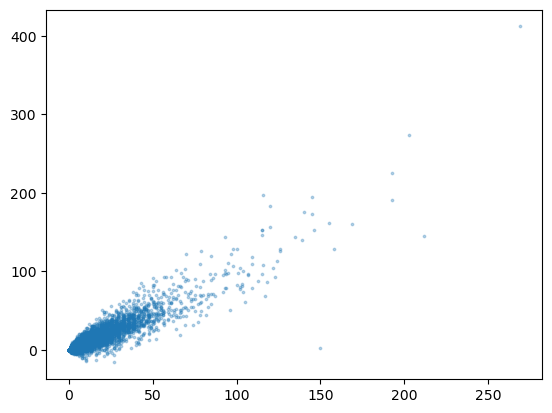

In [18]:
plt.scatter(
    s3_a_df['idr_psites'],
    -s3_a_df['pre-post'],
    s=3,
    alpha=0.3)
plt.show()

**BASE FUNCTIONS**

In [19]:
def nll(a, s, df):
    total = 0

    for i in range(len(df)):
        xi = df['idr_psites'][i]
        yi = -df['pre-post'][i]
        if xi == 0: continue
        sigma = s*math.sqrt(xi)
        total += ((yi - a*xi)/sigma)**2 * 0.5 + math.log(sigma*math.sqrt(2*math.pi))
    return total

def gauss_diff(d, sigma):
  return 1/(sigma*(2*math.pi)**(1/2))*math.exp(d**2/(-2*sigma**2))

def linear(x, a):
  return x * a

def show_fitted_line(a, df = s3_a_df, func = linear):
  min_sites = df['idr_psites'].min()
  max_sites = df['idr_psites'].max()

  x_line = np.linspace( min_sites, max_sites, 300 )
  y_line = func(x_line,a)
  plt.figure(figsize=(10, 6))
  plt.scatter(
      df['idr_psites'],
      -df['pre-post'],
      s=3,
      alpha=0.3,
  )


  num_bins = 50

  bins = np.linspace(min_sites, max_sites, num_bins + 1)
  df_copy = df.copy()
  df_copy['sites_bin'] = pd.cut(df_copy['idr_psites'], bins=bins, include_lowest=True)

  grouped = df_copy.groupby('sites_bin')['pre-post'].mean().reset_index()
  bin_midpoints = [(interval.left + interval.right) / 2 for interval in grouped['sites_bin']]
  plt.plot(bin_midpoints, -grouped['pre-post'], color='blue', linewidth=2, label='Mean of -pre-post in bins'
  )

  plt.plot(x_line, y_line, color='red', linewidth=2, label='Fitted model'
  )

  plt.xlim(0.0, 150)
  plt.ylim(0.0,150)
  plt.xlabel('Number of psites')
  plt.ylabel('Post-Pre')
  plt.title(' Pre-Post vs. Number of psites with average and fitted curve'
  )
  plt.legend()
  plt.grid(True, linestyle='--', alpha=0.6)
  plt.show()

def lcg(state, a, c, m):
    """The next state of a linear congruential generator: s_{i+1} = (a * s_i + c) mod m."""
    return (state*a + c) % m
A = 1664525
C = 1013904223
M = 2 ** 32
def uniforms(k, seed):
    """A list of k numbers on [0, 1): the generator run k times from the seed, each state divided by m."""
    out = [0.0] * k
    state = seed
    for i in range(k):
      state = lcg(state,A,C,M)
      out[i] = state / M
    return out




**FORWARD SIMULATION**

In [20]:
a = 1
sigma = 1
s = 1.5
INTERVALS_COUNT = 1000
df = s3_a_df

d = np.linspace(-5*sigma, 5*sigma, INTERVALS_COUNT)
mid = (d[:-1] + d[1:]) / 2
cdf = [gauss_diff(mid[0], sigma)]
for i in range(1, len(mid)):
    cdf.append(cdf[i-1] + gauss_diff(mid[i], sigma))
cdf = np.array(cdf)
cdf /= cdf[-1]

rs = np.array(uniforms(len(df), 2026))
noise = []
for r in rs:
    i = 0
    while cdf[i] < r:
        i += 1
    noise.append(mid[i])

x = df['idr_psites'].values
y_sim = a*x + s*np.sqrt(x)*noise
assert (-0.05 < np.mean(noise) < 0.05), f"The mean is not zero: {np.mean(noise)}"
print(f"ok  noise mean {np.mean(noise):.3f} is within {0.05:.3f} of zero")

ok  noise mean 0.006 is within 0.050 of zero


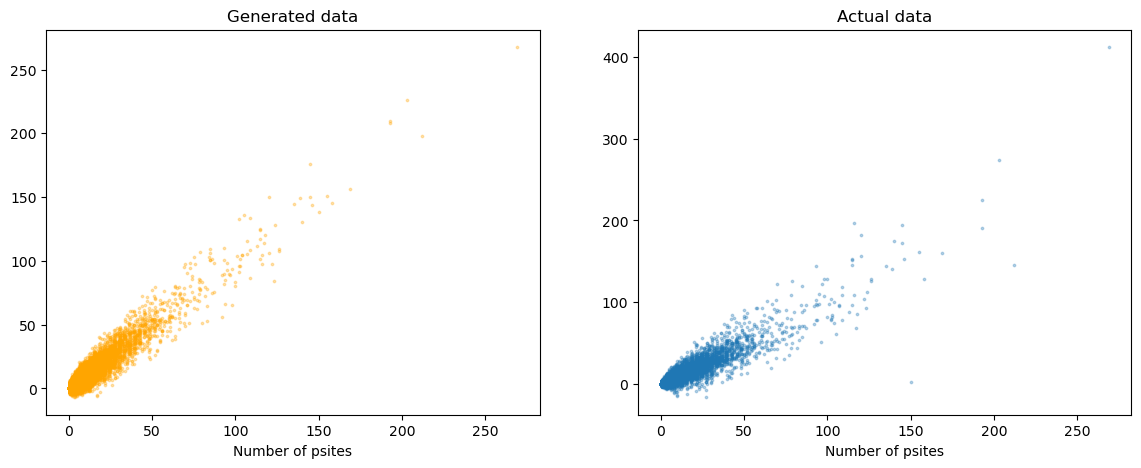

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


ax1.scatter(
    s3_a_df['idr_psites'], y_sim,
    s=3,
    alpha=0.3,
    color = "orange"
    )
ax1.set_title('Generated data')
ax1.set_xlabel('Number of psites')

ax2.scatter(
    s3_a_df['idr_psites'],
    -s3_a_df['pre-post'],
    s=3,
    alpha=0.3)
ax2.set_title('Actual data')
ax2.set_xlabel('Number of psites')
plt.show()




**FITTING**

In [22]:
def fit(alpha = 0.001, df = s3_a_df, tolerance = 0.001):
  CYCLES = 100
  N = (df['idr_psites'] > 0).sum()

  a,s = 1,1

  for c in range(CYCLES):
    if c % 1 == 0:
      print(f'Cycle {c}')
    a_der = 0
    s_der = N/s
    current_nll = nll(a, s, df)
    for i in range(len(df)):
      yi = -df['pre-post'][i]
      xi = df['idr_psites'][i]
      if xi == 0: continue
      mui = (a*xi)

      a_der += (mui - yi)/s**2
      s_der -= (mui - yi)**2 / (s**3*xi)
    if abs(a_der) < tolerance and abs(s_der) < tolerance:
      break
    a_new = a - alpha*a_der
    s_new = s - alpha*s_der
    new_nll = nll(a_new, s_new, df)
    if new_nll < current_nll:
        a, s = a_new, s_new
        alpha = alpha * 1.2
        current_nll = new_nll
    else:
        alpha = alpha * 0.5
  return a,s


In [23]:
a, sigma = fit()

Cycle 0
Cycle 1
Cycle 2
Cycle 3
Cycle 4
Cycle 5
Cycle 6
Cycle 7
Cycle 8
Cycle 9
Cycle 10
Cycle 11
Cycle 12
Cycle 13
Cycle 14
Cycle 15
Cycle 16
Cycle 17
Cycle 18
Cycle 19
Cycle 20
Cycle 21
Cycle 22
Cycle 23
Cycle 24
Cycle 25
Cycle 26
Cycle 27
Cycle 28
Cycle 29
Cycle 30
Cycle 31
Cycle 32
Cycle 33
Cycle 34
Cycle 35
Cycle 36
Cycle 37
Cycle 38
Cycle 39
Cycle 40
Cycle 41


a: 0.9275352253996765, sigma: 1.338996700121023


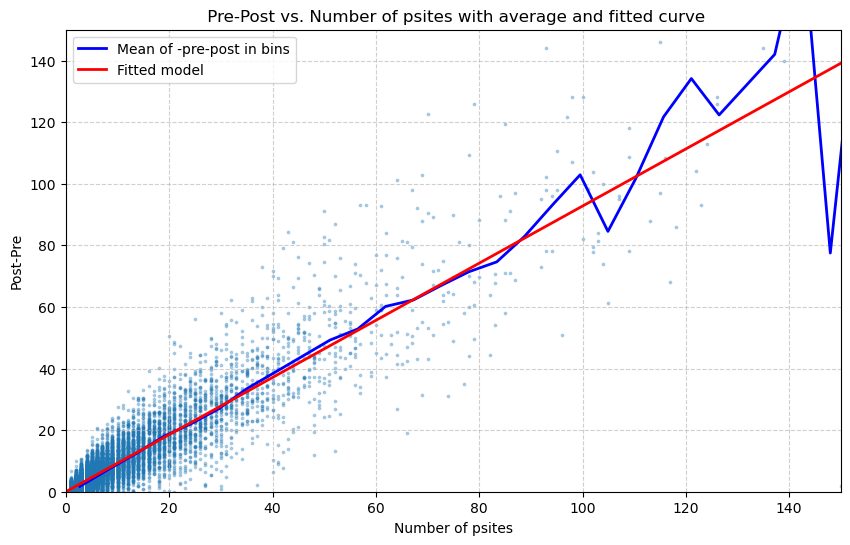

In [28]:
print(f"a: {a}, sigma: {sigma}")
show_fitted_line(a)

**BOOTSTRAPPING**

In [26]:
# Vectorize for faster versions of nll() and fit()
def nll_optimized(a, s, df):
    total = 0
    df_nonzero = df[df['idr_psites'] > 0]
    x = df_nonzero['idr_psites'].to_numpy()
    y = -df_nonzero['pre-post'].to_numpy()
    sigma = s * x**0.5
    
    total = (((y - a*x)/sigma)**2 * 0.5 + np.log(sigma*math.sqrt(2*math.pi))).sum()

    return total

def fit_optimized(alpha = 0.001, df = s3_a_df, tolerance = 0.001):
  CYCLES = 1000
  df_nonzero = df[df['idr_psites'] > 0]
  N = len(df_nonzero)

  a,s = 1,1

  for c in range(CYCLES):
    print(f"Cycle: {c}")
    current_nll = nll_optimized(a, s, df_nonzero)

    y =  -df_nonzero['pre-post'].to_numpy()
    x = df_nonzero['idr_psites'].to_numpy()

    mu = a*x
    a_der = ((mu - y)/s**2).sum()
    s_der = N/s - ((mu-y)**2/(s**3*x)).sum()

    if abs(a_der) < tolerance and abs(s_der) < tolerance:
      break
    a_new = a - alpha*a_der
    s_new = s - alpha*s_der
    new_nll = nll_optimized(a_new, s_new, df_nonzero)
    if new_nll < current_nll:
        a, s = a_new, s_new
        alpha = alpha * 1.2
        current_nll = new_nll
    else:
        alpha = alpha * 0.5
  return a,s

In [ ]:
# Fit draws with replacement to obtain parameter distributions
fitted_as = []
fitted_sigmas = []
num_bootstraps = 10000

for _ in range(num_bootstraps):
    boostrap_df = s3_a_df.sample(frac=1, replace=True).reset_index(drop=True)
    a, sigma = fit_optimized(df=boostrap_df)
    fitted_as.append(a)
    fitted_sigmas.append(sigma)

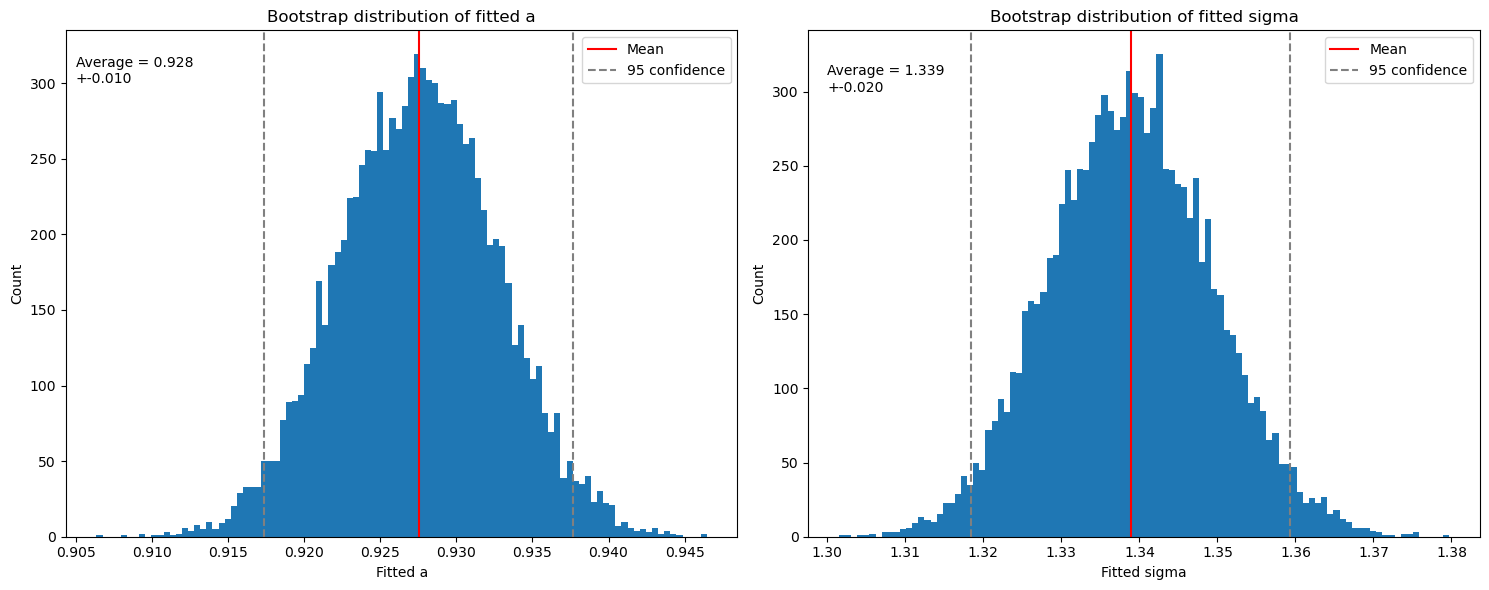

In [58]:
# Get means and 95% confidence intervals
mean_a = np.mean(fitted_as)
mean_sigma = np.mean(fitted_sigmas)

a_95 = np.std(fitted_as) * 1.96
sigma_95 = np.std(fitted_sigmas) * 1.96

# Plot histograms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.hist(fitted_as, bins=100)
ax1.axvline(mean_a, color='red', label='Mean')
ax1.axvline(mean_a+a_95, linestyle='dashed', color='grey', label='95 confidence')
ax1.axvline(mean_a-a_95, linestyle='dashed', color='grey')
ax1.text(s=f'Average = {mean_a:.3f}\n+-{a_95:.3f}',x=0.905,y=300)
ax1.set_title('Bootstrap distribution of fitted a')
ax1.set_xlabel('Fitted a')
ax1.set_ylabel('Count')
ax1.legend()

ax2.hist(fitted_sigmas, bins=100)
ax2.axvline(mean_sigma, color='red', label='Mean')
ax2.axvline(mean_sigma+sigma_95, linestyle='dashed', color='grey', label='95 confidence')
ax2.axvline(mean_sigma-sigma_95, linestyle='dashed', color='grey')
ax2.text(s=f'Average = {mean_sigma:.3f}\n+-{sigma_95:.3f}',x=1.3,y=300)
ax2.set_title('Bootstrap distribution of fitted sigma')
ax2.set_xlabel('Fitted sigma')
ax2.set_ylabel('Count')
ax2.legend()

plt.tight_layout()
plt.show()

**BREAKING THE MODEL**

**USER APPLICATION: ENTER AMINO ACID SEQUENCE**